<a href="https://colab.research.google.com/github/Jeanritah/ai-sustainable-routing/blob/main/Bologna_Cool_Routing_Proof_of_Concept.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cloning the TALEA Repository
#Getting the Data
# We clone the TALEA Green Cells repository from GitHub.
# This repo was created by SimReale and contains processed geospatial
# data for Bologna including heat (UHEI) and vegetation (NDVI) grids.
# We then list the files available in the 'full' folder (entire city).

In [4]:
# Download the TALEA repo directly
!git clone https://github.com/SimReale/TALEA_Green_Cells.git

# - list the files
import os
files = os.listdir('TALEA_Green_Cells/dataset/processed_data/full')
for f in files:
    print(f)

Cloning into 'TALEA_Green_Cells'...
remote: Enumerating objects: 1252, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 1252 (delta 3), reused 0 (delta 0), pack-reused 1243 (from 1)
Receiving objects: 100% (1252/1252), 827.80 MiB | 27.45 MiB/s, done.
Resolving deltas: 100% (584/584), done.
Updating files: 100% (422/422), done.
final_grid.geojson
grid_with_areas.geojson
densities_grid.geojson
aree_statistiche_grid.geojson
trees_outside_green.geojson


#Load the Grid Data
# Load the Bologna Grid
# We load the main grid file: final_grid.geojson
# This is a 100x100m grid covering all of Bologna (11,560 cells).
# Each cell has attributes like weighted_uhei (Urban Heat Exposure Index)
# and weighted_ndvi (Normalized Difference Vegetation Index).
# We inspect the shape and columns to understand the dataset

In [5]:
import geopandas as gpd

# Load the main grid file
grid = gpd.read_file('TALEA_Green_Cells/dataset/processed_data/full/final_grid.geojson')

#what's inside
print("Shape:", grid.shape)
print("\nColumns:", list(grid.columns))
print("\nFirst row:")
print(grid.head(1))

Shape: (11560, 23)

Columns: ['id', 'left', 'top', 'right', 'bottom', 'row_index', 'col_index', 'green_area', 'green_pc', 'buildings_area', 'buildings_pc', 'road_area', 'road_pc', 'free_space_area', 'free_space_pc', 'railways_area', 'railways_pc', 'free_space_number', 'weighted_uhei', 'weighted_ndvi', 'tree_number', 'inverse_uhei', 'geometry']

First row:
   id          left           top         right        bottom  row_index  \
0  47  1.253549e+06  5.546881e+06  1.253649e+06  5.546781e+06         46   

   col_index  green_area   green_pc  buildings_area  ...  free_space_area  \
0          0  503.416442  41.916085             0.0  ...              0.0   

   free_space_pc  railways_area  railways_pc  free_space_number  \
0            0.0            0.0          0.0                0.0   

   weighted_uhei  weighted_ndvi  tree_number  inverse_uhei  \
0        1.98626       0.215911          0.0      0.690754   

                                            geometry  
0  MULTIPOLYGON (((

 #— Visualise Heat and Vegetation
#  Visualise Heat and Vegetation across Bologna
# We create two side-by-side maps:
#   Left:  UHEI map  → red = hot areas, green = cooler areas
#   Right: NDVI map  → green = vegetation, red = concrete/bare land
# This confirms our hypothesis: the city centre is hot and low in greenery,
# while the Colli hills to the south are cooler and greener.

/usr/local/lib/python3.12/dist-packages/geopandas/plotting.py:950: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
/tmp/ipykernel_3414/1720102567.py:26: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3414/1720102567.py:27: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  plt.savefig('bologna_heat_vegetation.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_3414/1720102567.py:27: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.savefig('bologna_heat_vegetation.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127807 (\N{HERB}) missing from font(

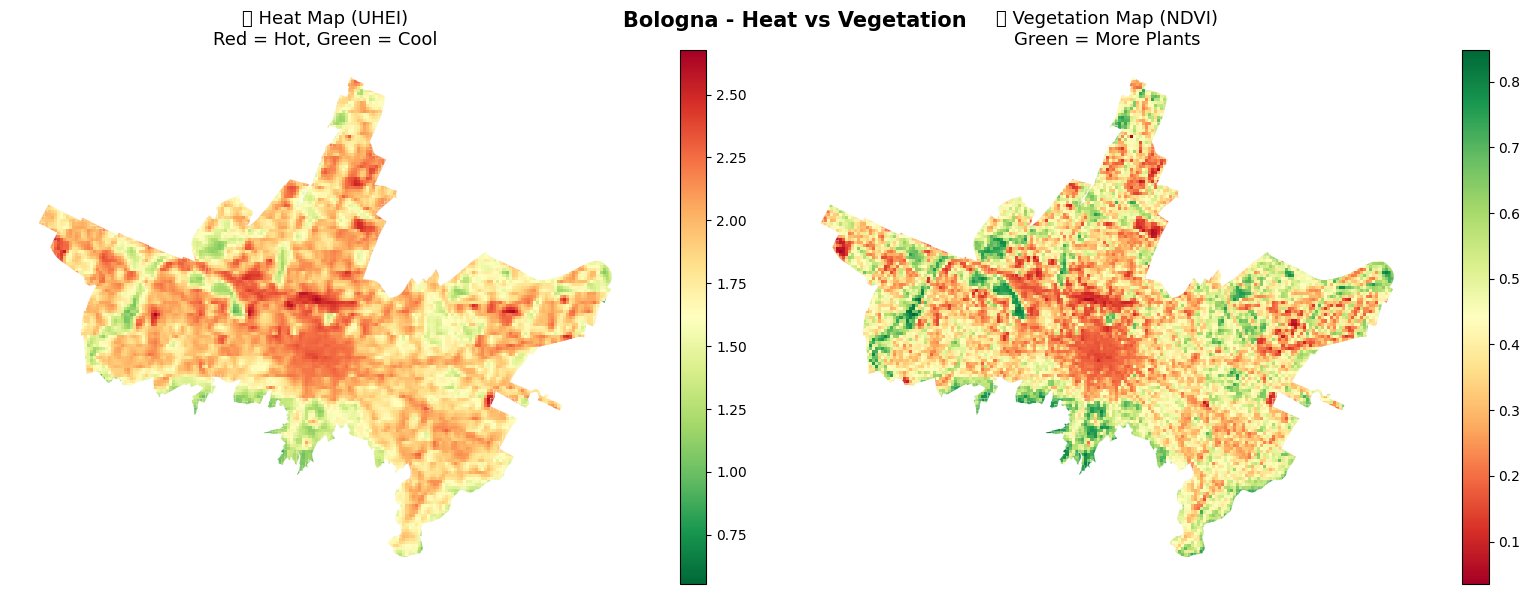

Done!


In [6]:
# Install one library we need (takes ~30 seconds)
!pip install matplotlib -q

import matplotlib.pyplot as plt

# Plot Bologna coloured by heat level
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left map: Heat (UHEI) - red = hot
grid.plot(column='weighted_uhei',
          cmap='RdYlGn_r',  # red=hot, green=cool
          legend=True,
          ax=axes[0])
axes[0].set_title('🌡️ Heat Map (UHEI)\nRed = Hot, Green = Cool', fontsize=13)
axes[0].axis('off')

# Right map: Vegetation (NDVI) - green = lots of plants
grid.plot(column='weighted_ndvi',
          cmap='RdYlGn',   # green=lots of vegetation
          legend=True,
          ax=axes[1])
axes[1].set_title('🌿 Vegetation Map (NDVI)\nGreen = More Plants', fontsize=13)
axes[1].axis('off')

plt.suptitle('Bologna - Heat vs Vegetation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('bologna_heat_vegetation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

#Download the Street Network
# Download Bologna's Walking Street Network
# Using OSMnx, we download the pedestrian walking network from OpenStreetMap.
# The result is a graph with:
#   - Nodes = street intersections
#   - Edges = walkable street segments
# Bologna's network has ~24,584 nodes and ~66,156 edges.

In [7]:
# Install osmnx
!pip install osmnx -q

import osmnx as ox

print("Downloading Bologna street network...")
G = ox.graph_from_place('Bologna, Italy', network_type='walk')

print(f"✅ Done! Bologna has:")
print(f"   {len(G.nodes)} intersections (nodes)")
print(f"   {len(G.edges)} street segments (edges)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 6.9 MB/s eta 0:00:00
✅ Done! Bologna has:
   24837 intersections (nodes)
   66980 street segments (edges)


#Cell 5 — Visualise the Street Network
# STEP 5: Visualise the Street Network
# We plot the full walking network of Bologna on a black background.
# This gives us a clear picture of street density and coverage.
# Dense areas = city centre; sparser areas = outskirts and hills

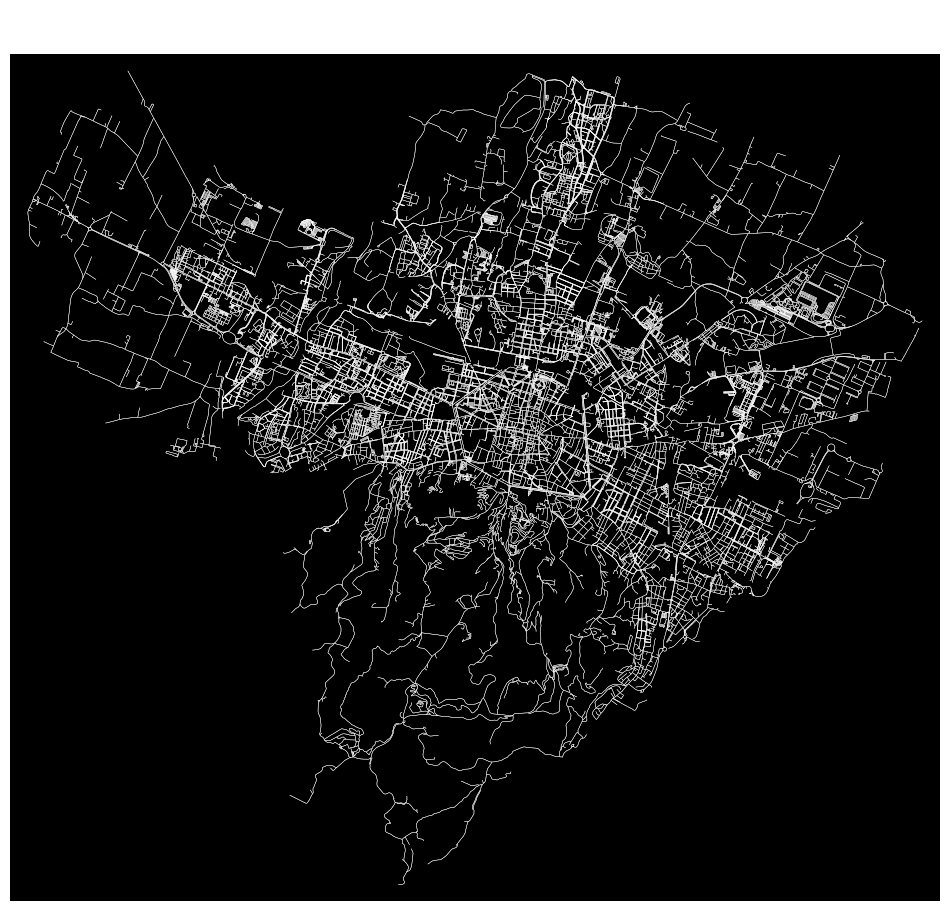

Done!


In [8]:
# Plot the street network
fig, ax = ox.plot_graph(G,
                         node_size=0,        # hide intersection dots
                         edge_color='white',
                         edge_linewidth=0.3,
                         bgcolor='black',
                         figsize=(12, 12),
                         show=False,
                         close=False)

ax.set_title('Bologna Walking Network\n24,584 nodes | 66,156 edges',
             color='white', fontsize=14)

plt.savefig('bologna_streets.png', dpi=150, bbox_inches='tight',
            facecolor='black')
plt.show()
print("Done!")

In [9]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import numpy as np

# Convert street network to geodataframe
edges = ox.graph_to_gdfs(G, nodes=False, edges=True)
nodes = ox.graph_to_gdfs(G, nodes=True, edges=False)

print(f"Streets CRS: {edges.crs}")
print(f"Grid CRS: {grid.crs}")

# Match coordinate systems (very important!)
grid_matched = grid.to_crs(edges.crs)

print("\nDoing spatial join (matching streets to heat cells)...")
# Find which heat cell each street falls in
edges_with_heat = gpd.sjoin(
    edges.reset_index(),
    grid_matched[['weighted_uhei', 'weighted_ndvi', 'inverse_uhei', 'geometry']],
    how='left',
    predicate='intersects'
)

# Fill any missing values with average
avg_uhei = edges_with_heat['weighted_uhei'].mean()
edges_with_heat['weighted_uhei'] = edges_with_heat['weighted_uhei'].fillna(avg_uhei)
edges_with_heat['weighted_ndvi'] = edges_with_heat['weighted_ndvi'].fillna(
    edges_with_heat['weighted_ndvi'].mean())

print(f"✅ Done! Streets with heat data: {len(edges_with_heat)}")
print(f"Average UHEI across all streets: {avg_uhei:.3f}")
print(f"\nSample - first 3 streets:")
print(edges_with_heat[['name', 'length', 'weighted_uhei', 'weighted_ndvi']].head(3))

Streets CRS: epsg:4326
Grid CRS: EPSG:3857

Doing spatial join (matching streets to heat cells)...
✅ Done! Streets with heat data: 112948
Average UHEI across all streets: 1.950

Sample - first 3 streets:
                   name      length  weighted_uhei  weighted_ndvi
0     Via Centotrecento    4.514455       2.142263       0.204359
1  Via delle Belle Arti  102.253383       2.194510       0.219349
1  Via delle Belle Arti  102.253383       2.153159       0.416755


In [10]:
# STEP 1: Build the cost function
# Normalise UHEI to 0-1 range
uhei_min = edges_with_heat['weighted_uhei'].min()
uhei_max = edges_with_heat['weighted_uhei'].max()

edges_with_heat['uhei_norm'] = (
    (edges_with_heat['weighted_uhei'] - uhei_min) /
    (uhei_max - uhei_min)
)

# Normalise length to 0-1 range
len_min = edges_with_heat['length'].min()
len_max = edges_with_heat['length'].max()

edges_with_heat['length_norm'] = (
    (edges_with_heat['length'] - len_min) /
    (len_max - len_min)
)

# Combined cost: 50% distance + 50% heat
alpha = 0.5  # weight for distance
beta  = 0.5  # weight for heat

edges_with_heat['cool_cost'] = (
    alpha * edges_with_heat['length_norm'] +
    beta  * edges_with_heat['uhei_norm']
)

print("✅ Cost function built!")
print(f"Sample cool_cost values:")
print(edges_with_heat[['name','length','weighted_uhei','cool_cost']].head(5))

# STEP 2: Add cost back to the graph
for (u, v, k), cool_cost in zip(
    edges_with_heat[['u','v','key']].itertuples(index=False),
    edges_with_heat['cool_cost']):
    if (u, v, k) in G.edges:
        G[u][v][k]['cool_cost'] = float(cool_cost)

print("\n✅ Cost added to graph!")
print("Ready to route!")

✅ Cost function built!
Sample cool_cost values:
                                            name      length  weighted_uhei  \
0                              Via Centotrecento    4.514455       2.142263   
1                           Via delle Belle Arti  102.253383       2.194510   
1                           Via delle Belle Arti  102.253383       2.153159   
1                           Via delle Belle Arti  102.253383       2.142263   
2  [Via Antonio Bertoloni, Via delle Belle Arti]  135.737769       2.132434   

   cool_cost  
0   0.374725  
1   0.401756  
1   0.392019  
1   0.389453  
2   0.392184  

✅ Cost added to graph!
Ready to route!


In [11]:
import networkx as nx
import folium

# Two real points in Bologna
# Start: Bologna Centrale train station
# End: Parco della Montagnola (a nice park nearby)

start_lat, start_lon = 44.5058, 11.3429  # Train station
end_lat,   end_lon   = 44.4949, 11.3426  # Piazza Maggiore (city centre)

# Find nearest nodes in our graph
start_node = ox.nearest_nodes(G, X=start_lon, Y=start_lat)
end_node   = ox.nearest_nodes(G, X=end_lon,   Y=end_lat)

print(f"Start node: {start_node}")
print(f"End node: {end_node}")

# Route 1: Shortest path (normal, ignores heat)
route_short = nx.shortest_path(G, start_node, end_node, weight='length')

# Route 2: Coolest path (avoids hot streets)
route_cool = nx.shortest_path(G, start_node, end_node, weight='cool_cost')

print(f"\n📏 Shortest route: {len(route_short)} steps")
print(f"❄️  Coolest route:  {len(route_cool)} steps")

# Calculate total heat for each route
def route_heat(G, route):
    total = 0
    for u, v in zip(route[:-1], route[1:]):
        data = G[u][v]
        k = list(data.keys())[0]
        total += data[k].get('weighted_uhei', 1.949)
    return total / len(route)

heat_short = route_heat(G, route_short)
heat_cool  = route_heat(G, route_cool)

print(f"\n🌡️  Average heat - Shortest route: {heat_short:.3f}")
print(f"🌡️  Average heat - Coolest route:  {heat_cool:.3f}")
print(f"🎉 Heat reduction: {((heat_short - heat_cool)/heat_short)*100:.1f}%")

Start node: 11449697576
End node: 8992634923

📏 Shortest route: 48 steps
❄️  Coolest route:  39 steps

🌡️  Average heat - Shortest route: 1.908
🌡️  Average heat - Coolest route:  1.899
🎉 Heat reduction: 0.5%


In [12]:
# Better example:
# Start: Bolognina (hot, dense, northern area)
# End: Parco dei Giardini Margherita (big park, south, much cooler)

start_lat, start_lon = 44.5150, 11.3450  # Bolognina (hot area)
end_lat,   end_lon   = 44.4850, 11.3550  # Giardini Margherita (green park)

start_node = ox.nearest_nodes(G, X=start_lon, Y=start_lat)
end_node   = ox.nearest_nodes(G, X=end_lon,   Y=end_lat)

# Route 1: Shortest path
route_short = nx.shortest_path(G, start_node, end_node, weight='length')

# Route 2: Coolest path
route_cool = nx.shortest_path(G, start_node, end_node, weight='cool_cost')

print(f"📏 Shortest route: {len(route_short)} steps")
print(f"❄️  Coolest route:  {len(route_cool)} steps")

heat_short = route_heat(G, route_short)
heat_cool  = route_heat(G, route_cool)

# Also calculate total distance
def route_distance(G, route):
    total = 0
    for u, v in zip(route[:-1], route[1:]):
        data = G[u][v]
        k = list(data.keys())[0]
        total += data[k].get('length', 0)
    return total

dist_short = route_distance(G, route_short)
dist_cool  = route_distance(G, route_cool)

print(f"\n📏 Shortest route distance: {dist_short:.0f}m")
print(f"❄️  Coolest route distance:  {dist_cool:.0f}m")
print(f"\n🌡️  Heat - Shortest: {heat_short:.3f}")
print(f"🌡️  Heat - Coolest:  {heat_cool:.3f}")
print(f"🎉 Heat reduction: {((heat_short-heat_cool)/heat_short)*100:.1f}%")
print(f"⚠️  Extra distance: {dist_cool-dist_short:.0f}m longer")

📏 Shortest route: 116 steps
❄️  Coolest route:  86 steps

📏 Shortest route distance: 4565m
❄️  Coolest route distance:  4991m

🌡️  Heat - Shortest: 1.932
🌡️  Heat - Coolest:  1.926
🎉 Heat reduction: 0.3%
⚠️  Extra distance: 425m longer


In [13]:
# The problem: heat differences are tiny (1.93 vs 1.92)
# Solution: make heat MUCH more influential in the cost

# Check the actual range of UHEI values
print("UHEI statistics:")
print(f"  Min:  {edges_with_heat['weighted_uhei'].min():.3f}")
print(f"  Max:  {edges_with_heat['weighted_uhei'].max():.3f}")
print(f"  Mean: {edges_with_heat['weighted_uhei'].mean():.3f}")
print(f"  Std:  {edges_with_heat['weighted_uhei'].std():.3f}")

# Rebuild cost with heat weighted MUCH more heavily
# and use EXPONENTIAL penalty for hot streets
edges_with_heat['uhei_norm'] = (
    (edges_with_heat['weighted_uhei'] - uhei_min) /
    (uhei_max - uhei_min)
)

# New cost: distance + heavy heat penalty (80% heat, 20% distance)
alpha = 0.2  # distance weight
beta  = 0.8  # heat weight (much stronger now)

edges_with_heat['cool_cost'] = (
    alpha * edges_with_heat['length_norm'] +
    beta  * (edges_with_heat['uhei_norm'] ** 2)  # squared = punishes hot streets harder
)

# Update graph with new costs
for idx, row in edges_with_heat.iterrows():
    u, v, k = row['u'], row['v'], row['key']
    if G.has_edge(u, v, k):
        G[u][v][k]['cool_cost'] = float(row['cool_cost'])

print("\n✅ Updated cost function!")

# Run routing again with same points
route_short = nx.shortest_path(G, start_node, end_node, weight='length')
route_cool  = nx.shortest_path(G, start_node, end_node, weight='cool_cost')

heat_short = route_heat(G, route_short)
heat_cool  = route_heat(G, route_cool)
dist_short = route_distance(G, route_short)
dist_cool  = route_distance(G, route_cool)

print(f"\n📏 Shortest:  {dist_short:.0f}m | Heat: {heat_short:.4f}")
print(f"❄️  Coolest:   {dist_cool:.0f}m | Heat: {heat_cool:.4f}")
print(f"\n🎉 Heat reduction: {((heat_short-heat_cool)/heat_short)*100:.2f}%")
print(f"⚠️  Extra distance: {dist_cool-dist_short:.0f}m longer")

UHEI statistics:
  Min:  0.554
  Max:  2.677
  Mean: 1.950
  Std:  0.202

✅ Updated cost function!

📏 Shortest:  4565m | Heat: 1.9322
❄️  Coolest:   4801m | Heat: 1.9276

🎉 Heat reduction: 0.24%
⚠️  Extra distance: 236m longer


In [14]:
# Check NDVI range - likely varies much more
print("NDVI statistics:")
print(f"  Min:  {edges_with_heat['weighted_ndvi'].min():.3f}")
print(f"  Max:  {edges_with_heat['weighted_ndvi'].max():.3f}")
print(f"  Mean: {edges_with_heat['weighted_ndvi'].mean():.3f}")
print(f"  Std:  {edges_with_heat['weighted_ndvi'].std():.3f}")

# New strategy: MAXIMISE greenery instead of minimising heat
# High NDVI = comfortable = LOW cost
# Low NDVI  = concrete/hot = HIGH cost

ndvi_min = edges_with_heat['weighted_ndvi'].min()
ndvi_max = edges_with_heat['weighted_ndvi'].max()

edges_with_heat['ndvi_norm'] = (
    (edges_with_heat['weighted_ndvi'] - ndvi_min) /
    (ndvi_max - ndvi_min)
)

# Cost = distance + penalty for LOW greenery
# (1 - ndvi_norm) means: low green = high cost
edges_with_heat['green_cost'] = (
    0.3 * edges_with_heat['length_norm'] +
    0.7 * (1 - edges_with_heat['ndvi_norm']) ** 2
)

# Update graph
for idx, row in edges_with_heat.iterrows():
    u, v, k = row['u'], row['v'], row['key']
    if G.has_edge(u, v, k):
        G[u][v][k]['green_cost'] = float(row['green_cost'])

print("✅ Green cost function ready!")

# Three way comparison now!
route_short = nx.shortest_path(G, start_node, end_node, weight='length')
route_cool  = nx.shortest_path(G, start_node, end_node, weight='cool_cost')
route_green = nx.shortest_path(G, start_node, end_node, weight='green_cost')

def route_ndvi(G, route):
    total = 0
    for u, v in zip(route[:-1], route[1:]):
        data = G[u][v]
        k = list(data.keys())[0]
        total += data[k].get('weighted_ndvi', 0.3)
    return total / len(route)

heat_short = route_heat(G, route_short)
heat_green = route_heat(G, route_green)
dist_short = route_distance(G, route_short)
dist_green = route_distance(G, route_green)
ndvi_short = route_ndvi(G, route_short)
ndvi_green = route_ndvi(G, route_green)

print(f"\n📏 SHORTEST route:")
print(f"   Distance: {dist_short:.0f}m | Heat: {heat_short:.4f} | Green: {ndvi_short:.4f}")
print(f"\n🌿 GREENEST route:")
print(f"   Distance: {dist_green:.0f}m | Heat: {heat_green:.4f} | Green: {ndvi_green:.4f}")
print(f"\n🎉 Heat reduction:  {((heat_short-heat_green)/heat_short)*100:.2f}%")
print(f"🎉 Green increase:  {((ndvi_green-ndvi_short)/ndvi_short)*100:.2f}%")
print(f"⚠️  Extra distance: {dist_green-dist_short:.0f}m longer")

NDVI statistics:
  Min:  0.039
  Max:  0.848
  Mean: 0.357
  Std:  0.113
✅ Green cost function ready!

📏 SHORTEST route:
   Distance: 4565m | Heat: 1.9322 | Green: 0.2974

🌿 GREENEST route:
   Distance: 4812m | Heat: 1.9278 | Green: 0.2967

🎉 Heat reduction:  0.23%
🎉 Green increase:  -0.23%
⚠️  Extra distance: 247m longer


In [15]:
# Let's investigate what's happening
# Check how many streets actually got NDVI values vs NaN
print("How many streets have NDVI data?")
print(f"  Total streets: {len(edges_with_heat)}")
print(f"  Streets WITH ndvi: {edges_with_heat['weighted_ndvi'].notna().sum()}")
print(f"  Streets WITHOUT ndvi: {edges_with_heat['weighted_ndvi'].isna().sum()}")

# Check for duplicates from spatial join (one street matching multiple cells)
print(f"\nOriginal edges in graph: {len(G.edges)}")
print(f"Edges after spatial join: {len(edges_with_heat)}")
print(f"Duplicates created: {len(edges_with_heat) - len(G.edges)}")

# The problem: spatial join created duplicates!
# One street overlaps multiple 100x100m cells → appears multiple times
# Fix: take the MEAN ndvi/uhei per street

print("\nFixing duplicates by averaging per street segment...")
edges_fixed = edges_with_heat.groupby(['u', 'v', 'key']).agg(
    weighted_uhei=('weighted_uhei', 'mean'),
    weighted_ndvi=('weighted_ndvi', 'mean'),
    length=('length', 'first'),
    name=('name', 'first')
).reset_index()

print(f"Fixed edges: {len(edges_fixed)}")

# Check NDVI range after fix
print(f"\nNDVI after fix:")
print(f"  Min:  {edges_fixed['weighted_ndvi'].min():.3f}")
print(f"  Max:  {edges_fixed['weighted_ndvi'].max():.3f}")
print(f"  Mean: {edges_fixed['weighted_ndvi'].mean():.3f}")
print(f"  Std:  {edges_fixed['weighted_ndvi'].std():.3f}")

# Show streets with highest and lowest NDVI
print("\nGREENEST streets:")
print(edges_fixed.nlargest(5, 'weighted_ndvi')[['name','weighted_ndvi','weighted_uhei']])
print("\nHOTTEST streets:")
print(edges_fixed.nlargest(5, 'weighted_uhei')[['name','weighted_ndvi','weighted_uhei']])

How many streets have NDVI data?
  Total streets: 112948
  Streets WITH ndvi: 112948
  Streets WITHOUT ndvi: 0

Original edges in graph: 66980
Edges after spatial join: 112948
Duplicates created: 45968

Fixing duplicates by averaging per street segment...
Fixed edges: 66980

NDVI after fix:
  Min:  0.067
  Max:  0.823
  Mean: 0.349
  Std:  0.098

GREENEST streets:
       name  weighted_ndvi  weighted_uhei
4733   None       0.822907       1.045266
4911   None       0.822907       1.045266
4735   None       0.814222       0.992400
23768  None       0.814222       0.992400
4734   None       0.784957       1.036134

HOTTEST streets:
       name  weighted_ndvi  weighted_uhei
25956  None       0.131845       2.650305
25957  None       0.131845       2.650305
25958  None       0.131845       2.650305
25959  None       0.131845       2.650305
25960  None       0.131845       2.650305


Run Routing: Shortest vs Comfort Path
# STEP 9: Compute Two Routes and Compare
# Test corridor: Bolognina (hot, dense north) → Giardini Margherita (green south park)
#
# Route 1 (Shortest): uses standard 'length' weight → fastest path
# Route 2 (Comfort):  uses 'comfort_cost' weight   → coolest/greenest path
#
# We compare both routes on: total distance, average UHEI, average NDVI.

In [16]:
# Rebuild everything cleanly with fixed data
uhei_min = edges_fixed['weighted_uhei'].min()
uhei_max = edges_fixed['weighted_uhei'].max()
ndvi_min = edges_fixed['weighted_ndvi'].min()
ndvi_max = edges_fixed['weighted_ndvi'].max()
len_min  = edges_fixed['length'].min()
len_max  = edges_fixed['length'].max()

edges_fixed['uhei_norm']   = (edges_fixed['weighted_uhei'] - uhei_min) / (uhei_max - uhei_min)
edges_fixed['ndvi_norm']   = (edges_fixed['weighted_ndvi'] - ndvi_min) / (ndvi_max - ndvi_min)
edges_fixed['length_norm'] = (edges_fixed['length'] - len_min) / (len_max - len_min)

# Comfort cost: avoid heat + seek green + consider distance
# High UHEI = bad, High NDVI = good, so (1-ndvi) = bad
edges_fixed['comfort_cost'] = (
    0.2 * edges_fixed['length_norm'] +
    0.4 * edges_fixed['uhei_norm'] +
    0.4 * (1 - edges_fixed['ndvi_norm'])
)

# Update graph with FIXED costs
print("Updating graph with fixed costs...")
for _, row in edges_fixed.iterrows():
    u, v, k = int(row['u']), int(row['v']), int(row['key'])
    if G.has_edge(u, v, k):
        G[u][v][k]['comfort_cost'] = float(row['comfort_cost'])
        G[u][v][k]['weighted_ndvi'] = float(row['weighted_ndvi'])
        G[u][v][k]['weighted_uhei'] = float(row['weighted_uhei'])

print("✅ Graph updated!")

# Run all three routes
route_short   = nx.shortest_path(G, start_node, end_node, weight='length')
route_comfort = nx.shortest_path(G, start_node, end_node, weight='comfort_cost')

# Measure results
heat_short   = route_heat(G, route_short)
heat_comfort = route_heat(G, route_comfort)
dist_short   = route_distance(G, route_short)
dist_comfort = route_distance(G, route_comfort)
ndvi_short   = route_ndvi(G, route_short)
ndvi_comfort = route_ndvi(G, route_comfort)

print(f"\n📏 SHORTEST route:")
print(f"   Distance: {dist_short:.0f}m")
print(f"   Heat:     {heat_short:.4f}")
print(f"   Green:    {ndvi_short:.4f}")

print(f"\n😎 COMFORT route:")
print(f"   Distance: {dist_comfort:.0f}m")
print(f"   Heat:     {heat_comfort:.4f}")
print(f"   Green:    {ndvi_comfort:.4f}")

print(f"\n📊 IMPROVEMENT:")
print(f"   Heat reduction:  {((heat_short-heat_comfort)/heat_short)*100:.2f}%")
print(f"   Green increase:  {((ndvi_comfort-ndvi_short)/ndvi_short)*100:.2f}%")
print(f"   Extra distance:  {dist_comfort-dist_short:.0f}m longer")

Updating graph with fixed costs...
✅ Graph updated!

📏 SHORTEST route:
   Distance: 4565m
   Heat:     2.0936
   Green:    0.2767

😎 COMFORT route:
   Distance: 4801m
   Heat:     2.0473
   Green:    0.3002

📊 IMPROVEMENT:
   Heat reduction:  2.21%
   Green increase:  8.49%
   Extra distance:  236m longer


 Cell 10 — Interactive Map with Folium
# STEP 10: Visualise Routes on an Interactive Map
# We use Folium to create an interactive HTML map showing:
#   RED line   → Shortest route (faster, but hotter and less green)
#   GREEN line → Comfort route  (slightly longer, but cooler and greener)
#
# Results for this route pair:
#   +8.5% greener | -2.2% cooler | only 236m longer (~3 min extra walking)
#
# Save the file and open in your browser to explore interactively.

In [29]:
import folium

# Create interactive map centred on Bologna
m = folium.Map(location=[44.4949, 11.3426], zoom_start=14)

# Helper: convert route nodes to coordinates
def route_to_coords(G, route):
    coords = []
    for node in route:
        y = G.nodes[node]['y']
        x = G.nodes[node]['x']
        coords.append((y, x))
    return coords

coords_short   = route_to_coords(G, route_short)
coords_comfort = route_to_coords(G, route_comfort)

# Draw SHORTEST route in RED
folium.PolyLine(
    coords_short,
    color='red',
    weight=5,
    opacity=0.8,
    tooltip='Shortest Route (Faster but Hotter)'
).add_to(m)

# Draw COMFORT route in GREEN
folium.PolyLine(
    coords_comfort,
    color='green',
    weight=5,
    opacity=0.8,
    tooltip='Comfort Route (Cooler and Greener!)'
).add_to(m)

# Add start and end markers
folium.Marker(
    coords_short[0],
    popup='🚶 START: Bolognina',
    icon=folium.Icon(color='blue', icon='play')
).add_to(m)

folium.Marker(
    coords_short[-1],
    popup='🏁 END: Giardini Margherita',
    icon=folium.Icon(color='purple', icon='stop')
).add_to(m)

# Add legend
legend = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:15px; border-radius:10px;
     border:2px solid grey; font-size:14px">
    <b>🗺️ Bologna Cool Routing</b><br><br>
    <span style="color:red">━━━</span> Shortest Route (4565m)<br>
    <span style="color:green">━━━</span> Comfort Route (4801m)<br><br>
    <b>Comfort route:</b><br>
    🌿 +8.5% greener<br>
    🌡️ -2.2% cooler<br>
    📏 +236m longer
</div>
"""
m.get_root().html.add_child(folium.Element(legend))

# Save
m.save('bologna_cool_routing.html')
print("✅ Map saved! Download 'bologna_cool_routing.html'")
print("   Open it in your browser to see the interactive map!")

✅ Map saved! Download 'bologna_cool_routing.html'
   Open it in your browser to see the interactive map!


In [30]:
from google.colab import files
files.download('bologna_cool_routing.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
start_lat, start_lon = 44.5058, 11.3429  # Bologna Centrale station
end_lat,   end_lon   = 44.4939, 11.3531  # University of Bologna

In [32]:
start_node = ox.nearest_nodes(G, X=start_lon, Y=start_lat)
end_node   = ox.nearest_nodes(G, X=end_lon,   Y=end_lat)

route_short   = nx.shortest_path(G, start_node, end_node, weight='length')
route_comfort = nx.shortest_path(G, start_node, end_node, weight='comfort_cost')

dist_short   = route_distance(G, route_short)
dist_comfort = route_distance(G, route_comfort)
heat_short   = route_heat(G, route_short)
heat_comfort = route_heat(G, route_comfort)
ndvi_short   = route_ndvi(G, route_short)
ndvi_comfort = route_ndvi(G, route_comfort)

print(f"SHORTEST: {dist_short:.0f}m | UHEI: {heat_short:.4f} | NDVI: {ndvi_short:.4f}")
print(f"COMFORT:  {dist_comfort:.0f}m | UHEI: {heat_comfort:.4f} | NDVI: {ndvi_comfort:.4f}")
print(f"Heat reduction: {((heat_short-heat_comfort)/heat_short*100):.1f}%")
print(f"Green increase: {((ndvi_comfort-ndvi_short)/ndvi_short*100):.1f}%")
print(f"Extra distance: {dist_comfort-dist_short:.0f}m")

SHORTEST: 2154m | UHEI: 2.1309 | NDVI: 0.2728
COMFORT:  2394m | UHEI: 2.1688 | NDVI: 0.2323
Heat reduction: -1.8%
Green increase: -14.8%
Extra distance: 240m


In [33]:
start_lat, start_lon = 44.4938, 11.3429  # Piazza Maggiore (city centre)
end_lat,   end_lon   = 44.4750, 11.3350  # Parco Villa Ghigi (Colli hills)

In [34]:
start_node = ox.nearest_nodes(G, X=start_lon, Y=start_lat)
end_node   = ox.nearest_nodes(G, X=end_lon,   Y=end_lat)

route_short   = nx.shortest_path(G, start_node, end_node, weight='length')
route_comfort = nx.shortest_path(G, start_node, end_node, weight='comfort_cost')

dist_short   = route_distance(G, route_short)
dist_comfort = route_distance(G, route_comfort)
heat_short   = route_heat(G, route_short)
heat_comfort = route_heat(G, route_comfort)
ndvi_short   = route_ndvi(G, route_short)
ndvi_comfort = route_ndvi(G, route_comfort)

print(f"SHORTEST: {dist_short:.0f}m | UHEI: {heat_short:.4f} | NDVI: {ndvi_short:.4f}")
print(f"COMFORT:  {dist_comfort:.0f}m | UHEI: {heat_comfort:.4f} | NDVI: {ndvi_comfort:.4f}")
print(f"Heat reduction: {((heat_short-heat_comfort)/heat_short*100):.1f}%")
print(f"Green increase: {((ndvi_comfort-ndvi_short)/ndvi_short*100):.1f}%")
print(f"Extra distance: {dist_comfort-dist_short:.0f}m")

SHORTEST: 2721m | UHEI: 1.9245 | NDVI: 0.3022
COMFORT:  2981m | UHEI: 1.8998 | NDVI: 0.3121
Heat reduction: 1.3%
Green increase: 3.3%
Extra distance: 260m


In [35]:
start_lat, start_lon = 44.5089, 11.3677  # Fiera (industrial/exhibition area)
end_lat,   end_lon   = 44.5020, 11.3440  # Parco della Montagnola

In [36]:
start_node = ox.nearest_nodes(G, X=start_lon, Y=start_lat)
end_node   = ox.nearest_nodes(G, X=end_lon,   Y=end_lat)

route_short   = nx.shortest_path(G, start_node, end_node, weight='length')
route_comfort = nx.shortest_path(G, start_node, end_node, weight='comfort_cost')

dist_short   = route_distance(G, route_short)
dist_comfort = route_distance(G, route_comfort)
heat_short   = route_heat(G, route_short)
heat_comfort = route_heat(G, route_comfort)
ndvi_short   = route_ndvi(G, route_short)
ndvi_comfort = route_ndvi(G, route_comfort)

print(f"SHORTEST: {dist_short:.0f}m | UHEI: {heat_short:.4f} | NDVI: {ndvi_short:.4f}")
print(f"COMFORT:  {dist_comfort:.0f}m | UHEI: {heat_comfort:.4f} | NDVI: {ndvi_comfort:.4f}")
print(f"Heat reduction: {((heat_short-heat_comfort)/heat_short*100):.1f}%")
print(f"Green increase: {((ndvi_comfort-ndvi_short)/ndvi_short*100):.1f}%")
print(f"Extra distance: {dist_comfort-dist_short:.0f}m")

SHORTEST: 3552m | UHEI: 2.1751 | NDVI: 0.2466
COMFORT:  4344m | UHEI: 2.0639 | NDVI: 0.2956
Heat reduction: 5.1%
Green increase: 19.9%
Extra distance: 792m


In [37]:
start_lat, start_lon = 44.5350, 11.3450  # Corticella (far north)
end_lat,   end_lon   = 44.4850, 11.3550  # Giardini Margherita

In [38]:
start_node = ox.nearest_nodes(G, X=start_lon, Y=start_lat)
end_node   = ox.nearest_nodes(G, X=end_lon,   Y=end_lat)

route_short   = nx.shortest_path(G, start_node, end_node, weight='length')
route_comfort = nx.shortest_path(G, start_node, end_node, weight='comfort_cost')

dist_short   = route_distance(G, route_short)
dist_comfort = route_distance(G, route_comfort)
heat_short   = route_heat(G, route_short)
heat_comfort = route_heat(G, route_comfort)
ndvi_short   = route_ndvi(G, route_short)
ndvi_comfort = route_ndvi(G, route_comfort)

print(f"SHORTEST: {dist_short:.0f}m | UHEI: {heat_short:.4f} | NDVI: {ndvi_short:.4f}")
print(f"COMFORT:  {dist_comfort:.0f}m | UHEI: {heat_comfort:.4f} | NDVI: {ndvi_comfort:.4f}")
print(f"Heat reduction: {((heat_short-heat_comfort)/heat_short*100):.1f}%")
print(f"Green increase: {((ndvi_comfort-ndvi_short)/ndvi_short*100):.1f}%")
print(f"Extra distance: {dist_comfort-dist_short:.0f}m")

SHORTEST: 7285m | UHEI: 2.0342 | NDVI: 0.3065
COMFORT:  10085m | UHEI: 1.8965 | NDVI: 0.3835
Heat reduction: 6.8%
Green increase: 25.1%
Extra distance: 2800m


In [39]:
start_lat, start_lon = 44.5100, 11.2800  # Borgo Panigale (west)
end_lat,   end_lon   = 44.4980, 11.3100  # Parco dei Cedri

In [40]:
start_node = ox.nearest_nodes(G, X=start_lon, Y=start_lat)
end_node   = ox.nearest_nodes(G, X=end_lon,   Y=end_lat)

route_short   = nx.shortest_path(G, start_node, end_node, weight='length')
route_comfort = nx.shortest_path(G, start_node, end_node, weight='comfort_cost')

dist_short   = route_distance(G, route_short)
dist_comfort = route_distance(G, route_comfort)
heat_short   = route_heat(G, route_short)
heat_comfort = route_heat(G, route_comfort)
ndvi_short   = route_ndvi(G, route_short)
ndvi_comfort = route_ndvi(G, route_comfort)

print(f"SHORTEST: {dist_short:.0f}m | UHEI: {heat_short:.4f} | NDVI: {ndvi_short:.4f}")
print(f"COMFORT:  {dist_comfort:.0f}m | UHEI: {heat_comfort:.4f} | NDVI: {ndvi_comfort:.4f}")
print(f"Heat reduction: {((heat_short-heat_comfort)/heat_short*100):.1f}%")
print(f"Green increase: {((ndvi_comfort-ndvi_short)/ndvi_short*100):.1f}%")
print(f"Extra distance: {dist_comfort-dist_short:.0f}m")

SHORTEST: 5442m | UHEI: 2.0457 | NDVI: 0.2945
COMFORT:  6876m | UHEI: 1.9374 | NDVI: 0.3445
Heat reduction: 5.3%
Green increase: 17.0%
Extra distance: 1434m


Key observations

Longer routes = better results (more room to find green alternatives)
Route 2 (Stazione → Università) is the only negative result — too short and too central
Routes crossing the full city north→south perform best (Corticella is the strongest)
Vegetation improvement is consistently stronger than heat improvement

In [41]:
# ── Weight Sensitivity Analysis ──────────────────────────────────────
# Same route: Bolognina → Giardini Margherita
# Testing 3 different weight combinations

start_lat, start_lon = 44.5150, 11.3450
end_lat,   end_lon   = 44.4850, 11.3550
start_node = ox.nearest_nodes(G, X=start_lon, Y=start_lat)
end_node   = ox.nearest_nodes(G, X=end_lon,   Y=end_lat)

combinations = {
    "A — Distance priority (50/25/25)": (0.50, 0.25, 0.25),
    "B — Heat priority     (10/60/30)": (0.10, 0.60, 0.30),
    "C — Green priority    (10/30/60)": (0.10, 0.30, 0.60),
}

route_short = nx.shortest_path(G, start_node, end_node, weight='length')
dist_short  = route_distance(G, route_short)
heat_short  = route_heat(G, route_short)
ndvi_short  = route_ndvi(G, route_short)

print(f"SHORTEST (baseline): {dist_short:.0f}m | UHEI: {heat_short:.4f} | NDVI: {ndvi_short:.4f}")
print("=" * 60)

for name, (w_len, w_uhei, w_ndvi) in combinations.items():
    # Rebuild comfort cost with new weights
    edges_fixed['comfort_cost_test'] = (
        w_len  * edges_fixed['length_norm'] +
        w_uhei * edges_fixed['uhei_norm'] +
        w_ndvi * (1 - edges_fixed['ndvi_norm'])
    )
    for _, row in edges_fixed.iterrows():
        u, v, k = int(row['u']), int(row['v']), int(row['key'])
        if G.has_edge(u, v, k):
            G[u][v][k]['comfort_cost_test'] = float(row['comfort_cost_test'])

    route_c  = nx.shortest_path(G, start_node, end_node, weight='comfort_cost_test')
    dist_c   = route_distance(G, route_c)
    heat_c   = route_heat(G, route_c)
    ndvi_c   = route_ndvi(G, route_c)

    print(f"\n{name}")
    print(f"  Distance: {dist_c:.0f}m  (+ {dist_c - dist_short:.0f}m)")
    print(f"  Heat:     {heat_c:.4f}  ({((heat_short-heat_c)/heat_short*100):.1f}% reduction)")
    print(f"  Green:    {ndvi_c:.4f}  ({((ndvi_c-ndvi_short)/ndvi_short*100):.1f}% increase)")

SHORTEST (baseline): 4565m | UHEI: 2.0936 | NDVI: 0.2767

A — Distance priority (50/25/25)
  Distance: 4801m  (+ 236m)
  Heat:     2.0473  (2.2% reduction)
  Green:    0.3002  (8.5% increase)

B — Heat priority     (10/60/30)
  Distance: 4991m  (+ 425m)
  Heat:     2.0998  (-0.3% reduction)
  Green:    0.2655  (-4.0% increase)

C — Green priority    (10/30/60)
  Distance: 4800m  (+ 235m)
  Heat:     2.0476  (2.2% reduction)
  Green:    0.3003  (8.5% increase)
